- Decision Tree

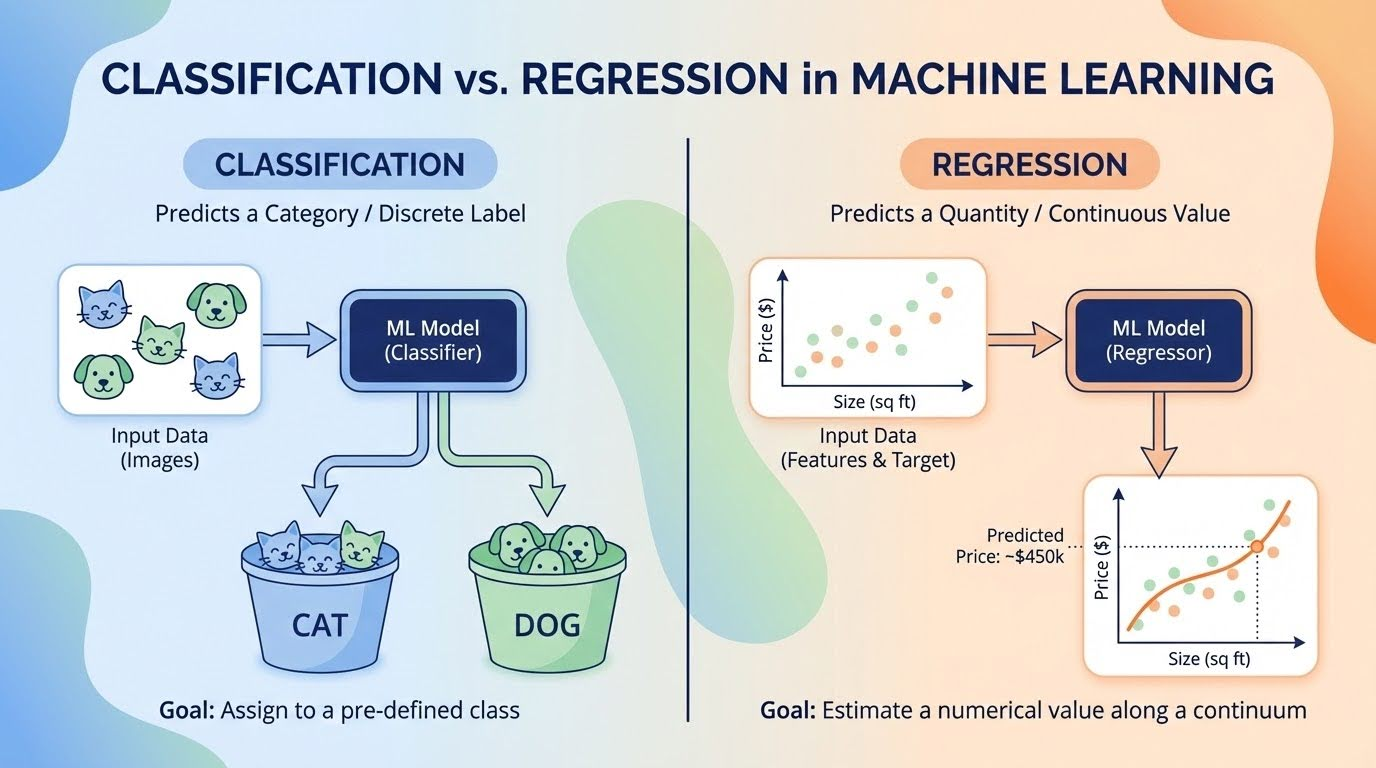

## Classification models in machine learning
- **Data:** Divided into predefined , discrete group
- **Goal** Assign an input to one specific 

## Decision Tree
- a rule based method used for decision making
- It can be applied to Classification/Regression problem

## Decision tree python implementation of job offer dataset

### Import libraries

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier,plot_tree
import matplotlib.pyplot as plt    # optional
import seaborn as sns              # optional

In [2]:
df=pd.read_csv("https://raw.githubusercontent.com/patelmanishv/Sem4Data/refs/heads/main/Datasets/job_offers.csv")
df.head(2)

,CGPA,Communication,Aptitude,ProgrammingSkill,JobOffered
0,2,1,1,1,1
1,1,1,1,1,1


In [3]:
# define features and target
x=df.drop(columns=["JobOffered"])
y=df["JobOffered"]
print(x.shape)
print(y.shape)

(20, 4)
(20,)


### create a model


In [4]:
dtree=DecisionTreeClassifier(criterion='entropy',max_depth=3)

In [5]:
dtree.fit(x,y)

,criterion,'entropy'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Predictions

In [11]:
predictions=dtree.predict(x)
print(predictions)

[1 1 0 0 1 1 0 0 1 1 0 0 1 0 0 0 0 0 0 1]


### Plot the tree (not in syllabus)

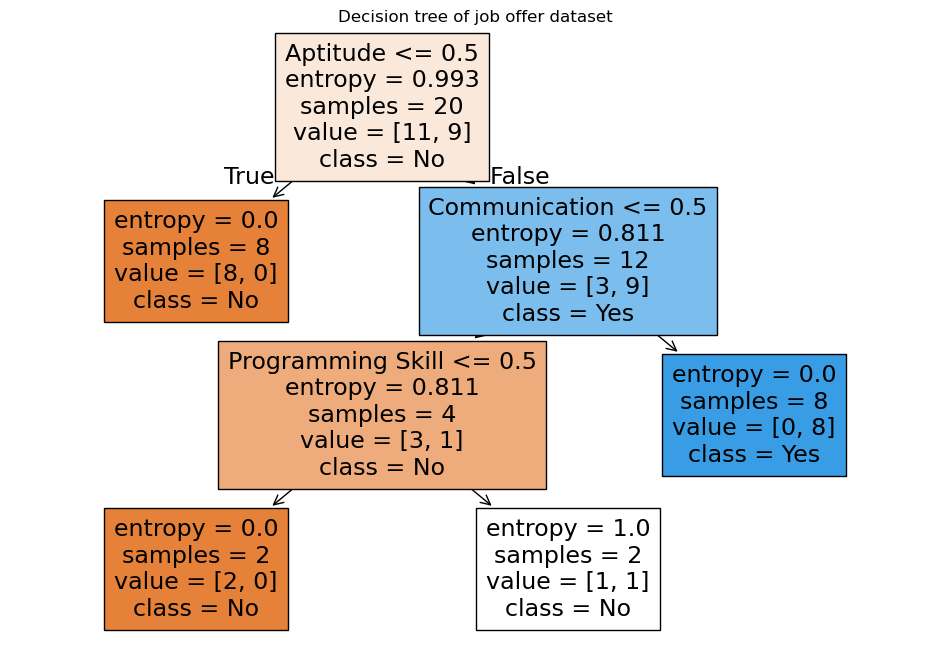

In [12]:
plt.figure(figsize=(12,8))
plot_tree(dtree,filled=True,
         feature_names=['CGPA','Communication','Aptitude','Programming Skill'],
          class_names=['No','Yes'])
plt.title("Decision tree of job offer dataset")
plt.show()

### Evaluation Metrics in classification models
- confusion matrix
- accuracy score
- precision score
- recall score
- f1 score
- classification report

In [9]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,classification_report

### confusion matrix

In [13]:
cm=confusion_matrix(y,predictions)
print("confusion matrix - \n ",cm)

confusion matrix - 
  [[11  0]
 [ 1  8]]


In [16]:
TN,FP,FN,TP=cm.ravel()
print("True Negatives ",TN)
print("False Positives ",FP)
print("False Negatives ",FN)
print("True Positives ",TP)

True Negatives  11
False Positives  0
False Negatives  1
True Positives  8


### Accuracy score
- accuracyscore=(TN+TP)/(TN+FN+FP+TP)

In [18]:
accuracyscore=(TN+TP)/(TN+FN+FP+TP)
print("accuracy of model is ",accuracyscore)
print("error rate is ",1-accuracyscore)

accuracy of model is  0.95
error rate is  0.050000000000000044


### Precision score
- precisionscore=TP/(TP+FP)

In [23]:
precisionscore=TP/(TP+FP)
print("precision score is",precisionscore)
print(precision_score(y,predictions))

precision score is 1.0
1.0


### Recall 
- recallscore=TP/(TP+FN)

In [22]:
recallscore=TP/(TP+FN)
print("Recall score is",recallscore)
print(recall_score(y,predictions))

Recall score is 0.8888888888888888
0.8888888888888888


### f1 score
- f1score=2*(precisionscore*recallscore)/(precisionscore+recallscore)

In [24]:
f1score=2*(precisionscore*recallscore)/(precisionscore+recallscore)
print("f1score is ",f1score)
print(f1_score(y,predictions))

f1score is  0.9411764705882353
0.9411764705882353


### classification report
- the metrics report

In [25]:
print(classification_report(y,predictions))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        11
           1       1.00      0.89      0.94         9

    accuracy                           0.95        20
   macro avg       0.96      0.94      0.95        20
weighted avg       0.95      0.95      0.95        20



### Plot the confusion matrix

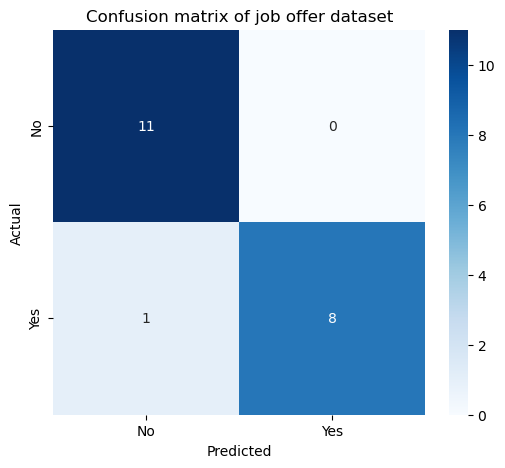

In [26]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,xticklabels=['No','Yes'],
                     yticklabels=['No','Yes'],fmt='d',cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix of job offer dataset")
plt.show()          